# 案例 02 · 高原与高温：浦东—乌鲁木齐—喀什

**场景**：七月的一个午后，一架窄体机执行浦东（ZSPD，标高 13 ft）→ 乌鲁木齐（ZWWW，2,126 ft），
后续还要飞喀什（ZWSH，4,424 ft）。西北的夏天午后 35 °C 很常见——**高温 + 高标高**同时抬高密度高度，
让同样的起飞重量需要更长的跑道。这个案例用工具包的启发式场长模型量化"还剩多少余量"，
并用简化油量政策核算这条航线的备降方案。

**诚实话**：场长修正是**教学级启发式**（基础值 + 每千英尺 +7% / ISA+每度 +0.6% / 每米秒逆风 −1%），
不含机型具体的起飞推力、襟翼、V1 决策等真实要素；结论只用于展示修正的**方向和量级**，
不代表任何真实机型的起飞性能。见 [docs/methodology.md](../docs/methodology.md)。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from routelab.airports import AirportDB
from routelab.fuel import FuelPolicy, block_fuel
from routelab.performance import ProxyAircraft, takeoff_field_length_m

db = AirportDB()
PROXY = ProxyAircraft()  # A320neo-class proxy (C919 stand-in)

def isa_temp_c(elev_ft: float) -> float:
    # ISA temperature at a pressure altitude (about -1.98 C per 1000 ft)
    return 15.0 - 1.9812 * elev_ft / 1000.0

# 夏季午后的假设温度（典型气候值，教学假设）
SUMMER_T_C = {"ZSPD": 33.0, "ZWWW": 34.0, "ZWSH": 34.0, "ZPPP": 24.0}

rows = []
for ident in SUMMER_T_C:
    ap = db.get(ident)
    t_isa = isa_temp_c(ap.elevation_ft)
    t_sum = SUMMER_T_C[ident]
    rows.append({
        "机场": f"{ap.ident} {ap.iata}", "名称": ap.name,
        "标高 ft": ap.elevation_ft,
        "最长跑道 m": db.max_runway_m(ap),
        "ISA 温度 °C": t_isa,
        "假设夏季温度 °C": t_sum,
        "ISA 偏差 °C": t_sum - t_isa,
    })
airports = pd.DataFrame(rows)
airports.round(1)

,机场,名称,标高 ft,最长跑道 m,ISA 温度 °C,假设夏季温度 °C,ISA 偏差 °C
0,ZSPD PVG,Shanghai Pudong International Airport,13.0,4000.0,15.0,33.0,18.0
1,ZWWW URC,Urumqi Diwopu International Airport,2126.0,3600.0,10.8,34.0,23.2
2,ZWSH KHG,Kashgar Airport,4420.0,3200.0,6.2,34.0,27.8
3,ZPPP KMG,Kunming Changshui International Airport,6903.0,4500.0,1.3,24.0,22.7


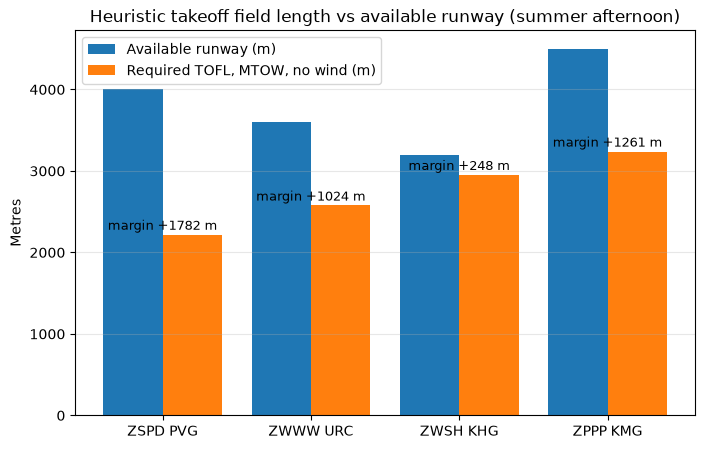

,机场,标高 ft,ISA 偏差 °C,最长跑道 m,需要场长 m,跑道余量 m
0,ZSPD PVG,13.0,18.0,4000.0,2218.0,1782.0
1,ZWWW URC,2126.0,23.0,3600.0,2576.0,1024.0
2,ZWSH KHG,4420.0,28.0,3200.0,2952.0,248.0
3,ZPPP KMG,6903.0,23.0,4500.0,3239.0,1261.0


In [2]:
# 昆明（ZPPP，6,903 ft）作为"高原但不热"的对照组一并看
def summer_tofl_m(ident: str) -> float:
    # Required TOFL at the assumed summer temperature, MTOW, no wind
    ap = db.get(ident)
    return takeoff_field_length_m(ap.elevation_ft, SUMMER_T_C[ident] - isa_temp_c(ap.elevation_ft))

airports_plot = airports.copy()
airports_plot["需要场长 m"] = [summer_tofl_m(i) for i in SUMMER_T_C]
airports_plot["跑道余量 m"] = airports_plot["最长跑道 m"] - airports_plot["需要场长 m"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(airports_plot))
ax.bar(x - 0.2, airports_plot["最长跑道 m"], width=0.4, label="Available runway (m)")
ax.bar(x + 0.2, airports_plot["需要场长 m"], width=0.4, label="Required TOFL, MTOW, no wind (m)")
for xi, margin in zip(x, airports_plot["跑道余量 m"]):
    ax.annotate(f"margin {margin:+.0f} m", (xi, airports_plot["需要场长 m"].iloc[int(xi)] + 60),
                ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(airports_plot["机场"])
ax.set_ylabel("Metres")
ax.set_title("Heuristic takeoff field length vs available runway (summer afternoon)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.show()
airports_plot[["机场", "标高 ft", "ISA 偏差 °C", "最长跑道 m", "需要场长 m", "跑道余量 m"]].round(0)

**读数**：在"满载、无风、无净空/障碍物修正"的假设下，四个机场的启发式需要场长都还在跑道长度以内，
余量从浦东的 ~1.7 km 到喀什的 ~0.2 km 递减——**喀什（高 + 热）是最紧的**，这正是西北夏季运行的真实痛点方向。

## 1. 温度敏感性：每个机场"热到几度会顶满跑道"？

把温度从 ISA 扫到 50 °C，看需要场长何时追上可用跑道（**临界温度**）：

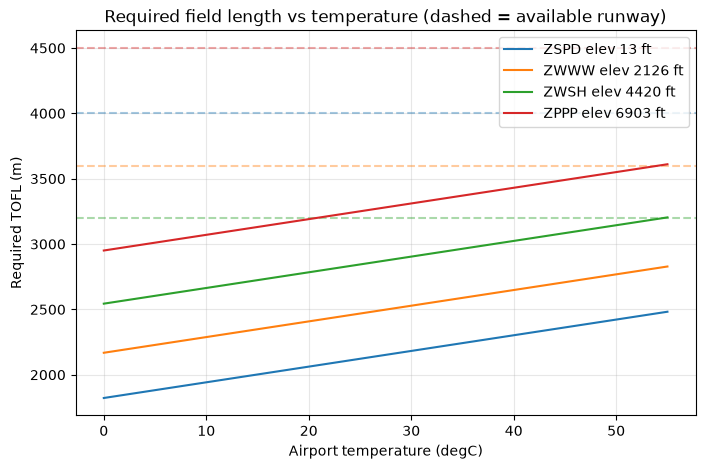

,机场,可用跑道 m,临界温度 °C,典型七月午后 °C,裕度 °C
0,ZSPD,4000.0,NaN,33.0,NaN
1,ZWWW,3600.0,NaN,34.0,NaN
2,ZWSH,3200.0,55.0,34.0,21.0
3,ZPPP,4500.0,NaN,24.0,NaN


In [3]:
temps = np.linspace(0, 55, 221)
fig, ax = plt.subplots(figsize=(8, 5))
crit_rows = []
for ident in SUMMER_T_C:
    ap = db.get(ident)
    req = [takeoff_field_length_m(ap.elevation_ft, t - isa_temp_c(ap.elevation_ft)) for t in temps]
    ax.plot(temps, req, label=f"{ap.ident} elev {ap.elevation_ft:.0f} ft")
    avail = db.max_runway_m(ap)
    ax.axhline(avail, color=ax.lines[-1].get_color(), ls="--", alpha=0.4)
    hit = [t for t, r in zip(temps, req) if r >= avail]
    crit_rows.append({
        "机场": ap.ident,
        "可用跑道 m": avail,
        "临界温度 °C": min(hit) if hit else None,
        "典型七月午后 °C": SUMMER_T_C[ident],
    })
ax.set_xlabel("Airport temperature (degC)")
ax.set_ylabel("Required TOFL (m)")
ax.set_title("Required field length vs temperature (dashed = available runway)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
crit = pd.DataFrame(crit_rows)
crit["裕度 °C"] = crit["临界温度 °C"] - crit["典型七月午后 °C"]
crit.round(0)

## 2. 航段油量：浦东 → 乌鲁木齐，备降喀什

航程油 + 5% 绕飞 + 备降航段（乌鲁木齐 → 喀什，约 1,066 km）+ 30 min 最终储备 + 滑行，
逐项算出轮档油，再检查 15 t 业载下是否可行：

In [4]:
leg = db.route("ZSPD", "ZWWW")
div = db.route("ZWWW", "ZWSH")
print(f"{leg.origin} -> {leg.destination}: {leg.distance_km:.0f} km   "
      f"alternate {div.origin} -> {div.destination}: {div.distance_km:.0f} km")

policy = FuelPolicy()
trip = PROXY.cruise_fuel_kg_per_h * (leg.distance_km / PROXY.cruise_tas_kmh
                                     + PROXY.climb_descent_extra_h)
b = block_fuel(PROXY, trip, div.distance_km, policy)
table = pd.DataFrame([
    ("Trip 浦东-乌鲁木齐", b.trip_kg),
    ("Contingency 5%", b.contingency_kg),
    ("Alternate 乌鲁木齐-喀什 + 进近", b.alternate_kg),
    ("Final reserve 30 min", b.final_reserve_kg),
    ("Taxi", b.taxi_kg),
    ("BLOCK 轮档油", b.block_kg),
], columns=["item", "kg"])

PAYLOAD_KG = 15_000
fuel_limit = min(PROXY.max_fuel_kg, PROXY.max_usable_weight_kg - PAYLOAD_KG)
verdict = "OK" if b.block_kg <= fuel_limit else "NOT FEASIBLE"
print(f"payload {PAYLOAD_KG} kg + block {b.block_kg:.0f} kg "
      f"vs weight/tank limit {fuel_limit:.0f} kg -> {verdict}")
table.round(0)

ZSPD -> ZWWW: 3312 km   alternate ZWWW -> ZWSH: 1066 km
payload 15000 kg + block 15038 kg vs weight/tank limit 19000 kg -> OK


,item,kg
0,Trip 浦东-乌鲁木齐,9606.0
1,Contingency 5%,480.0
2,Alternate 乌鲁木齐-喀什 + 进近,3602.0
3,Final reserve 30 min,1150.0
4,Taxi,200.0
5,BLOCK 轮档油,15038.0


**读数**：轮档油里备降喀什这一项就占 ~3 t——备降场选得远，代价直接写进油量。这就是"备降场选择"是运行控制核心工作的原因。

## 3. 讨论：高原高温为什么咬人，以及运营上怎么办

- **机理**：起飞拉力与升力都随空气密度下降；标高抬高压强，温度再抬密度，两者叠加 = 密度高度远高于标高。
  喀什标高 4,424 ft + 午后 34 °C 的密度高度大约相当于 7,000+ ft 的标准大气——**感觉上是在一座"更高的机场"起飞**；
- **代价**：同样的起飞重量需要更长滑跑；跑道不够时只能**减载**（拆客/货）或**减油**（加限制航段），
  或者避开午后高温、改成清晨低温时刻起飞；
- **对照**：昆明标高 6,903 ft 比喀什高得多，但夏季凉爽（ISA 偏差小），启发式余量反而更大——
  **"高原"与"高温"两个因素要分开看，谁主导取决于 ISA 偏差**；
- **模型局限**：本工具的场长公式与重量无关（隐含"总是 MTOW 起飞"），无风修正极粗糙，
  没有障碍物/净空、刹车能量、V1 速度等真实要素。真实签派用 AFM 性能图表或软件（如 ACARS 起飞数据）计算。

**局限**：所有数字为教学级量级演示；C919 无公开性能数据，使用 A320neo 级代理机型；
机场/跑道数据为内置 OurAirports 样本（公有领域）。